# Prompt Importance

**Feeds:** RQ1 (prompt sensitivity, PT vs EN). This notebook also produces
`best_templates.json`, the best-template-per-(model, language) artifact
that notebooks 02-04 depend on -- **run this notebook first**.

Uses `results/prompt_selection/{portuguese,english}/results.csv`: 8 prompt
templates (`cls`, `cls_def`, `cls_def_exp`, `cls_exp`, `ext`, `ext_def`,
`ext_def_exp`, `ext_exp`) x up to 5 models, evaluated on the 20
prompt-selection documents.


In [36]:
import sys
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import _common as c

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 100)


In [37]:
BASE_TEMPLATES = ["cls", "cls_def",  "ext", "ext_def", "cls_def_exp", "cls_exp", "ext_def_exp", "ext_exp"]

results = pd.concat([c.load_results("prompt_selection", lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
results = results[results["template"].isin(BASE_TEMPLATES) & (results["model"] != "llama32_3b")].reset_index(drop=True)
results.head()

,model,template,entity,precision,recall,f1,f1_r,stage,language
0,gemini,ext,participants,0.272727,0.063098,0.102484,0.784992,prompt_selection,portuguese
1,gemini,ext_def,participants,0.240000,0.068834,0.106984,0.788684,prompt_selection,portuguese
2,gemini,cls,participants,0.278607,0.214149,0.242162,0.713382,prompt_selection,portuguese
3,gemini,cls_def,participants,0.362745,0.212237,0.267793,0.791372,prompt_selection,portuguese
4,gemini,ext_exp,participants,0.542461,0.598470,0.569091,0.725934,prompt_selection,portuguese


## Combined view: Precision/Recall/F1 distribution per template

The per-model bar charts above are informative but noisy -- each template's
signal is split across 5 models x multiple entities. Pooling across models
and entities (same `results` frame as above, already restricted to
`BASE_TEMPLATES`) into one boxplot per template isolates the template effect:
it shows whether a template (e.g. the `*_exp` family) is consistently better,
rather than better for just one model. Kept split by language (as in the bar
charts above), since PT vs EN prompt sensitivity is part of RQ1.

C:\Users\davib\AppData\Local\Temp\ipykernel_19092\996469707.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(BASE_TEMPLATES, rotation=45, ha="right")
C:\Users\davib\AppData\Local\Temp\ipykernel_19092\996469707.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(BASE_TEMPLATES, rotation=45, ha="right")


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\01_combined_boxplot_by_template_language.pdf


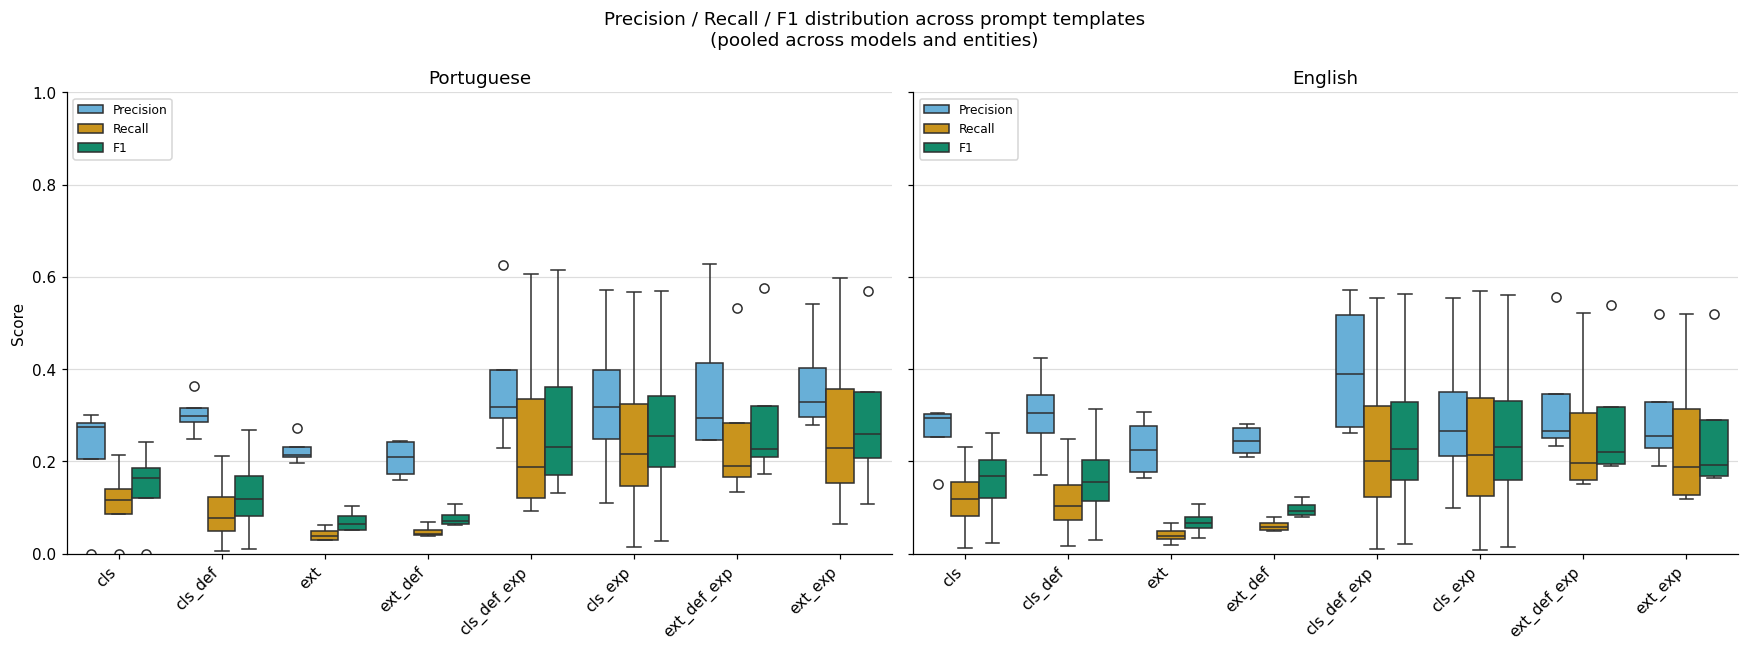

In [38]:
METRIC_ORDER = ["precision", "recall", "f1"]
METRIC_LABELS = {"precision": "Precision", "recall": "Recall", "f1": "F1"}
METRIC_COLORS = {"precision": "#56B4E9", "recall": "#E69F00", "f1": "#009E73"}

metric_long = results.melt(
    id_vars=["template", "language"],
    value_vars=METRIC_ORDER,
    var_name="metric",
    value_name="score",
)
metric_long["metric"] = metric_long["metric"].map(METRIC_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, lang in zip(axes, c.LANGUAGE_ORDER):
    sub = metric_long[metric_long["language"] == lang]
    sns.boxplot(
        data=sub,
        x="template",
        y="score",
        hue="metric",
        order=BASE_TEMPLATES,
        hue_order=[METRIC_LABELS[m] for m in METRIC_ORDER],
        palette={METRIC_LABELS[m]: METRIC_COLORS[m] for m in METRIC_ORDER},
        ax=ax,
    )
    ax.set_xticklabels(BASE_TEMPLATES, rotation=45, ha="right")
    ax.set_title(lang.capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend(title=None, loc="upper left", fontsize=8)
    c.style_axis(ax)
fig.suptitle("Precision / Recall / F1 distribution across prompt templates\n(pooled across models and entities)")
c.save_fig(fig, "01_combined_boxplot_by_template_language")
plt.show()


## F1 and F1-r across templates, per model and language

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\01_f1_by_template_model_language.pdf


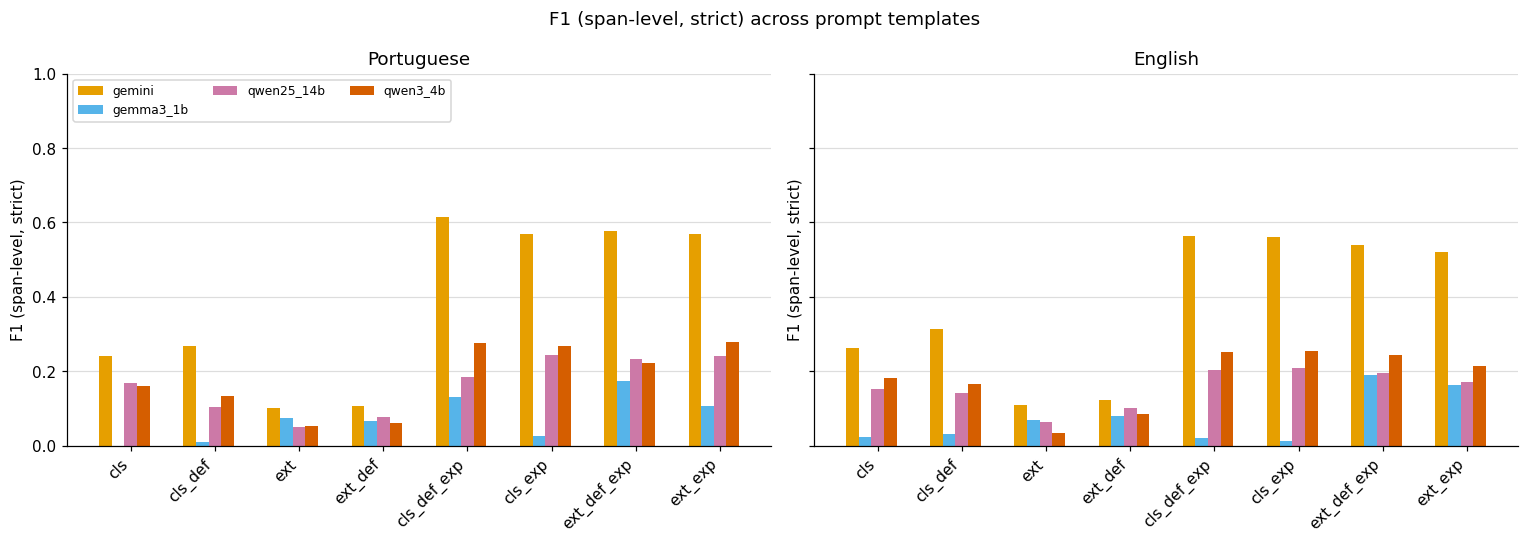

In [39]:
def plot_metric_by_template(metric, ylabel, fname):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, lang in zip(axes, c.LANGUAGE_ORDER):
        sub = results[results["language"] == lang]
        for i, model in enumerate(c.MODEL_ORDER):
            m = sub[sub["model"] == model].set_index("template").reindex(BASE_TEMPLATES)
            x = np.arange(len(BASE_TEMPLATES)) + (i - 2) * 0.15
            ax.bar(x, m[metric].values, width=0.15, color=c.MODEL_COLORS[model], label=model)
        ax.set_xticks(np.arange(len(BASE_TEMPLATES)))
        ax.set_xticklabels(BASE_TEMPLATES, rotation=45, ha="right")
        ax.set_title(lang.capitalize())
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1)
        c.style_axis(ax)
    axes[0].legend(loc="upper left", fontsize=8, ncol=3)
    fig.suptitle(ylabel + " across prompt templates")
    c.save_fig(fig, fname)
    plt.show()


plot_metric_by_template("f1", "F1 (span-level, strict)", "01_f1_by_template_model_language")


### Best F1 template per model

The bar chart above suggests the `*_exp` templates dominate, but that's hard
to read off 8 clustered bars per model. A heatmap of F1 by (model, template),
with each model's best template outlined, makes the pattern explicit.

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\01_best_template_heatmap.pdf


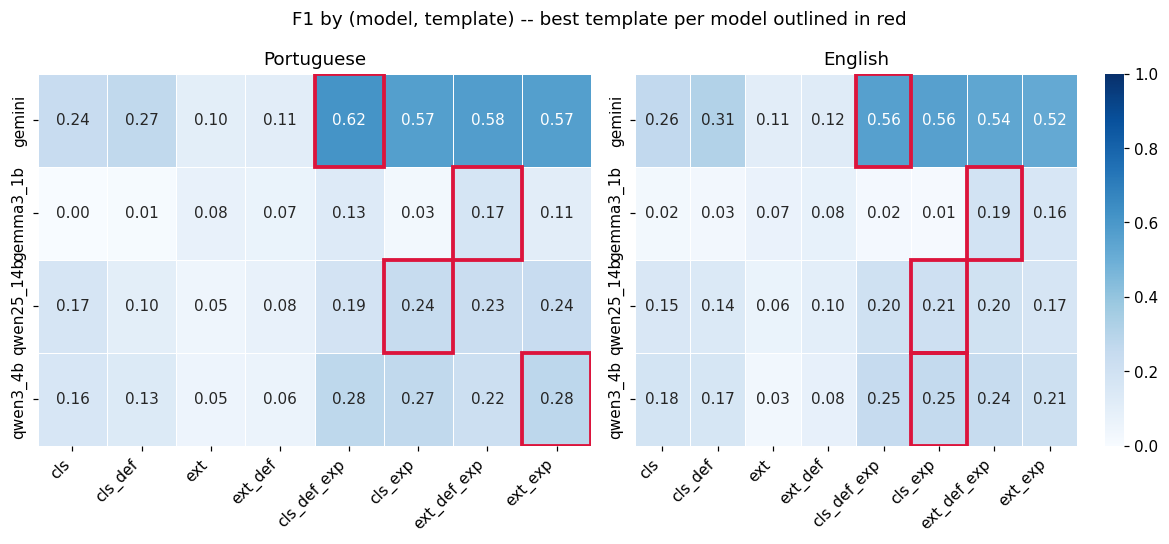

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for i, (ax, lang) in enumerate(zip(axes, c.LANGUAGE_ORDER)):
    sub = results[results["language"] == lang]
    pivot = sub.pivot(index="model", columns="template", values="f1").reindex(index=c.MODEL_ORDER, columns=BASE_TEMPLATES)
    sns.heatmap(
        pivot, ax=ax, cmap=c.HEATMAP_CMAP, vmin=0, vmax=1, annot=True, fmt=".2f",
        cbar=(i == len(c.LANGUAGE_ORDER) - 1), linewidths=0.5, linecolor="white",
    )
    for row_i, model in enumerate(pivot.index):
        col_i = pivot.loc[model].values.argmax()
        ax.add_patch(plt.Rectangle((col_i, row_i), 1, 1, fill=False, edgecolor="crimson", lw=2.5))
    ax.set_title(lang.capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.suptitle("F1 by (model, template) -- best template per model outlined in red")
c.save_fig(fig, "01_best_template_heatmap")
plt.show()


## Prompt sensitivity: dispersion of F1 across templates

In [42]:
disp = (
    results.groupby(["language", "model"])["f1"]
    .agg(std="std", min="min", max="max")
    .assign(range=lambda d: d["max"] - d["min"])
    .reset_index()
)
disp


,language,model,std,min,max,range
0,english,gemini,0.196241,0.108192,0.562977,0.454785
1,english,gemma3_1b,0.068093,0.013962,0.191111,0.177150
2,english,qwen25_14b,0.051688,0.062914,0.208284,0.145370
3,english,qwen3_4b,0.081526,0.033670,0.254346,0.220676
4,portuguese,gemini,0.223385,0.102484,0.615534,0.513050
5,portuguese,gemma3_1b,0.060883,0.000000,0.173482,0.173482
6,portuguese,qwen25_14b,0.076893,0.050676,0.242945,0.192269
7,portuguese,qwen3_4b,0.093027,0.052980,0.278044,0.225064


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\01_prompt_sensitivity_dispersion.pdf


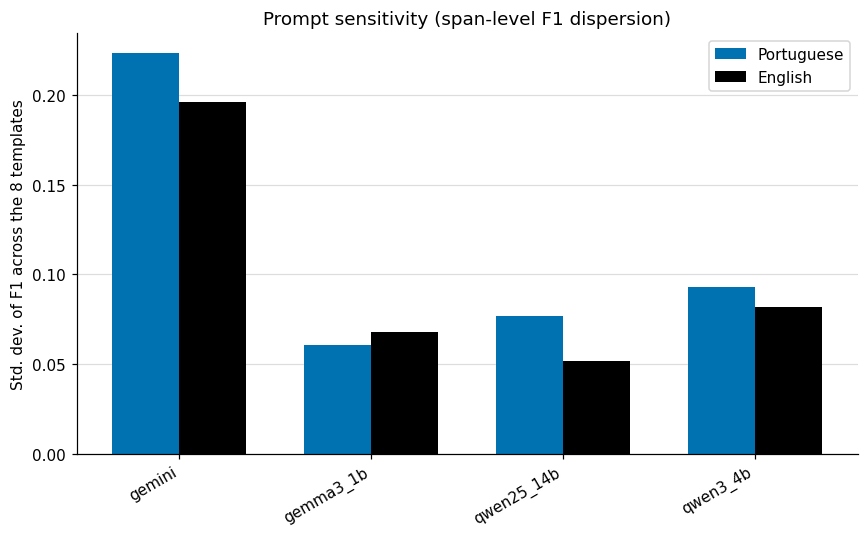

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(c.MODEL_ORDER))
width = 0.35
for i, lang in enumerate(c.LANGUAGE_ORDER):
    sub = disp[disp["language"] == lang].set_index("model").reindex(c.MODEL_ORDER)
    ax.bar(x + (i - 0.5) * width, sub["std"].values, width=width, color=c.LANGUAGE_COLORS[lang], label=lang.capitalize())
ax.set_xticks(x)
ax.set_xticklabels(c.MODEL_ORDER, rotation=30, ha="right")
ax.set_ylabel("Std. dev. of F1 across the 8 templates")
ax.set_title("Prompt sensitivity (span-level F1 dispersion)")
ax.legend()
c.style_axis(ax)
c.save_fig(fig, "01_prompt_sensitivity_dispersion")
plt.show()


## Determining the best template per (model, language)

Best template = argmax F1 only (no F1-r tie-break), for consistency with
the F1 heatmap above. Exported to `best_templates.json` for reuse by
notebooks 02-04.

In [44]:
best_rows = results.sort_values("f1", ascending=False).drop_duplicates(subset=["language", "model"], keep="first")

best_templates = {}
for lang in c.LANGUAGE_ORDER:
    lang_rows = best_rows[best_rows["language"] == lang]
    best_templates[lang] = dict(zip(lang_rows["model"], lang_rows["template"]))

best_templates

{'portuguese': {'gemini': 'cls_def_exp',
  'qwen3_4b': 'ext_exp',
  'qwen25_14b': 'cls_exp',
  'gemma3_1b': 'ext_def_exp'},
 'english': {'gemini': 'cls_def_exp',
  'qwen3_4b': 'cls_exp',
  'qwen25_14b': 'cls_exp',
  'gemma3_1b': 'ext_def_exp'}}

In [45]:
path = c.save_best_templates(best_templates)
print(f"Saved best templates to {path}")


Saved best templates to C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\notebooks\results\best_templates.json


## Supplementary: PT-only decoding-config sensitivity (test stage)\n\nGemini's PT test run was additionally swept over temperature/delimiter/role/CoT settings on top of the `cls_def_exp` base template. English has no equivalent ablation data -- this subsection is PT-only.

In [46]:
test_pt = c.load_results("test", "portuguese")
ablation = test_pt[test_pt["template"].str.startswith("cls_def_exp_temp")].copy()
ablation["temperature"] = ablation["template"].str.extract(r"temp([\d.]+)").astype(float)
ablation["delim"] = ablation["template"].str.contains("nodelim").map({True: "no delim", False: "delim"})
ablation["role"] = ablation["template"].str.contains("norole").map({True: "no role", False: "role"})
ablation["cot"] = ablation["template"].str.contains("nocot").map({True: "no CoT", False: "CoT"})
ablation[["template", "temperature", "delim", "role", "cot", "f1", "f1_r"]].sort_values("f1", ascending=False)


,template,temperature,delim,role,cot,f1,f1_r
3,cls_def_exp_temp0.0_nodelim_norole_nocot,0.0,no delim,no role,no CoT,0.558140,0.850009
1,cls_def_exp_temp0.0_delim_role_cot,0.0,delim,role,CoT,0.551546,0.803367
4,cls_def_exp_temp0.3_delim_role_nocot,0.3,delim,role,no CoT,0.541301,0.771708
2,cls_def_exp_temp0.0_delim_role_nocot,0.0,delim,role,no CoT,0.540321,0.771288
5,cls_def_exp_temp0.3_nodelim_norole_nocot,0.3,no delim,no role,no CoT,0.506607,0.730436
6,cls_def_exp_temp0.6_nodelim_norole_nocot,0.6,no delim,no role,no CoT,0.506083,0.737146
7,cls_def_exp_temp1.0_nodelim_norole_nocot,1.0,no delim,no role,no CoT,0.477778,0.757923


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\01_decoding_ablation_pt_only.pdf


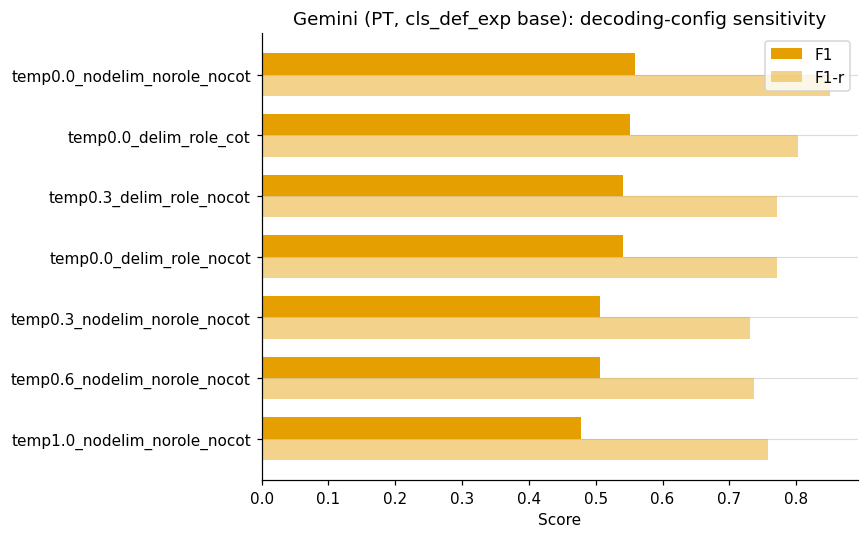

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
ablation_sorted = ablation.sort_values("f1")
labels = ablation_sorted["template"].str.replace("cls_def_exp_", "", regex=False)
y = np.arange(len(labels))
h = 0.35
ax.barh(y + h / 2, ablation_sorted["f1"], height=h, color=c.MODEL_COLORS["gemini"], label="F1")
ax.barh(y - h / 2, ablation_sorted["f1_r"], height=h, color=c.MODEL_COLORS["gemini"], alpha=0.45, label="F1-r")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Score")
ax.set_title("Gemini (PT, cls_def_exp base): decoding-config sensitivity")
ax.legend()
c.style_axis(ax)
c.save_fig(fig, "01_decoding_ablation_pt_only")
plt.show()


## Synthesis

- Feeds **RQ1**: the `*_exp` templates (`cls_exp`, `cls_def_exp`, `ext_exp`, `ext_def_exp`) take the four highest
  median-F1 ranks out of the 8 templates, in both languages (see the heatmap and the combined
  boxplot) -- and are the argmax-F1 best template for every one of the 4 models, in both
  languages (`best_templates.json` below). Adding a worked example to the prompt is the single
  largest lever on span-extraction reliability observed here, ahead of adding a class definition
  or switching between classify (`cls_*`) and extract (`ext_*`) framing.
- Prompt sensitivity (F1 std/range across the 8 templates) is highest for `gemini` (std ~0.20,
  range ~0.45-0.51) and lowest for `qwen25_14b` and `gemma3_1b` (std ~0.05-0.08) in both
  languages -- larger/more capable does not mean less prompt-sensitive here; `qwen3_4b` sits in
  between (std ~0.08-0.09).
- `best_templates.json` now holds the best (model, language) template pair -- argmax F1 only, no
  F1-r tie-break, for consistency with the heatmap -- consumed by notebooks 02-04.
- The PT-only decoding-config ablation gives a secondary read on how much of Gemini's variance is
  prompt-*content* sensitivity (this section) vs. decoding-*setting* sensitivity (previous section).
- `llama32_3b` is excluded throughout (see the note at the top of this notebook and
  `_common.EXCLUDED_MODELS`): its results are invalid, not just weak.
- Numeric interpretation to be condensed into `report/Chapters/Results.tex` prose in a future
  iteration (see the plan's RQ map).